#Imports#

In [1]:
from google.colab import drive
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import colorcet as cc
import calendar
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import plotly.graph_objs as go
from plotly.subplots import make_subplots

In [2]:
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
cd gdrive/MyDrive/finalized_data

/content/gdrive/MyDrive/finalized_data


In [4]:
# Questions
# Negative values in SWC/RH/Tair
# T_20 Station 5

In [5]:
#['Ppt_x','SWC_5','SWC_10','SWC_20','SWC_50','T_5','T_10','T_20','T_50','Flag','Ppt_y','Tair','RH','Windspeed','Winddirection','Srad','Month']

#Preprocessing#

In [6]:
df1 = pd.read_csv("Station1_Final_Version.csv", sep = ",", parse_dates = ['Unnamed: 0'], index_col = 'Unnamed: 0')
df2 = pd.read_csv("Station2_Final_Version.csv", sep  = ",", parse_dates = ['Unnamed: 0'], index_col = 'Unnamed: 0')
df3 = pd.read_csv("Station3_Final_Version.csv", sep = ",", parse_dates = ['Unnamed: 0'], index_col = 'Unnamed: 0')
df4 = pd.read_csv("Station4_Final_Version.csv", sep = ",", parse_dates = ['Unnamed: 0'], index_col = 'Unnamed: 0')
df5 = pd.read_csv("Station5_Final_Version.csv", sep = ",", parse_dates = ['Unnamed: 0'], index_col = 'Unnamed: 0')
df6 = pd.read_csv("Station6_Final_Version.csv", sep = ",", parse_dates = ['Unnamed: 0'], index_col = 'Unnamed: 0')

In [7]:
dfList = [df1, df2, df3, df4, df5, df6]
labels = ['df1', 'df2', 'df3', 'df4', 'df5', 'df6']

In [8]:
# Convert index column of each dataframe from str to datetime format

for df in dfList:
  df.index = pd.to_datetime(df.index)

#Line Plots#

##Soil Water Content (SWC)##

In [ ]:
# Create line plots for soil water content values for each depth at each station

SWC_List = ['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50']

for swc in SWC_List:
  fig = go.Figure()

  for df, label in zip(dfList, labels):
      fig.add_trace(go.Scatter(x = df.index, y = df[swc], mode = 'lines', name = label))

  fig.update_layout(
      height = 600,
      width = 1200,
      title_text = swc + " Values over Time - All Stations",
      xaxis_title = 'Time',
      yaxis_title = swc,
      legend_title = "StationID"
  )

  fig.show()

##Soil Temperature##

In [ ]:
# Create line plots for soil temperatures values at each depth at each station

T_List = ['T_5', 'T_10', 'T_20', 'T_50']

for t in T_List:
  fig = go.Figure()

  for df, label in zip(dfList, labels):
      fig.add_trace(go.Scatter(x = df.index, y = df[t], mode = 'lines', name = label))

  fig.update_layout(
      height = 600,
      width = 1200,
      title_text = t + " Values over Time - All Stations",
      xaxis_title = 'Time',
      yaxis_title = t,
      legend_title = "StationID"
  )

  fig.show()

##Other Features##

In [ ]:
# Create line plots for soil temperatures values at each depth at each station

f_List = ['Ppt_x']

for f in f_List:
  fig = go.Figure()

  for df, label in zip(dfList, labels):
      fig.add_trace(go.Scatter(x = df.index, y = df[f], mode = 'lines', name = label))

  fig.update_layout(
      height = 500,
      width = 1000,
      title_text = f + " Values over Time - All Stations",
      xaxis_title = 'Time',
      yaxis_title = f,
      legend_title = "StationID"
  )

  fig.show()

#Box Plots#

## Soil Water Content (SWC) - All Stations##

In [12]:
# Add month column for creation of seasonal box plots

for df in dfList:
  df['Month'] = df.index.month
  df['Month'] = df['Month'].apply(lambda x: calendar.month_name[x])
  month_order = [calendar.month_name[i] for i in range(1, 13)]
  df1['Month'] = pd.Categorical(df1['Month'], categories = month_order, ordered = True)

In [13]:
# Concatenate all dataframe to plot features side-by-side

df1['StationID'] = 'Station1'
df2['StationID'] = 'Station2'
df3['StationID'] = 'Station3'
df4['StationID'] = 'Station4'
df5['StationID'] = 'Station5'
df6['StationID'] = 'Station6'

df_all = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index = False)

df_all['Month'] = pd.Categorical(df_all['Month'], categories = [calendar.month_name[i] for i in range(1, 13)], ordered = True)

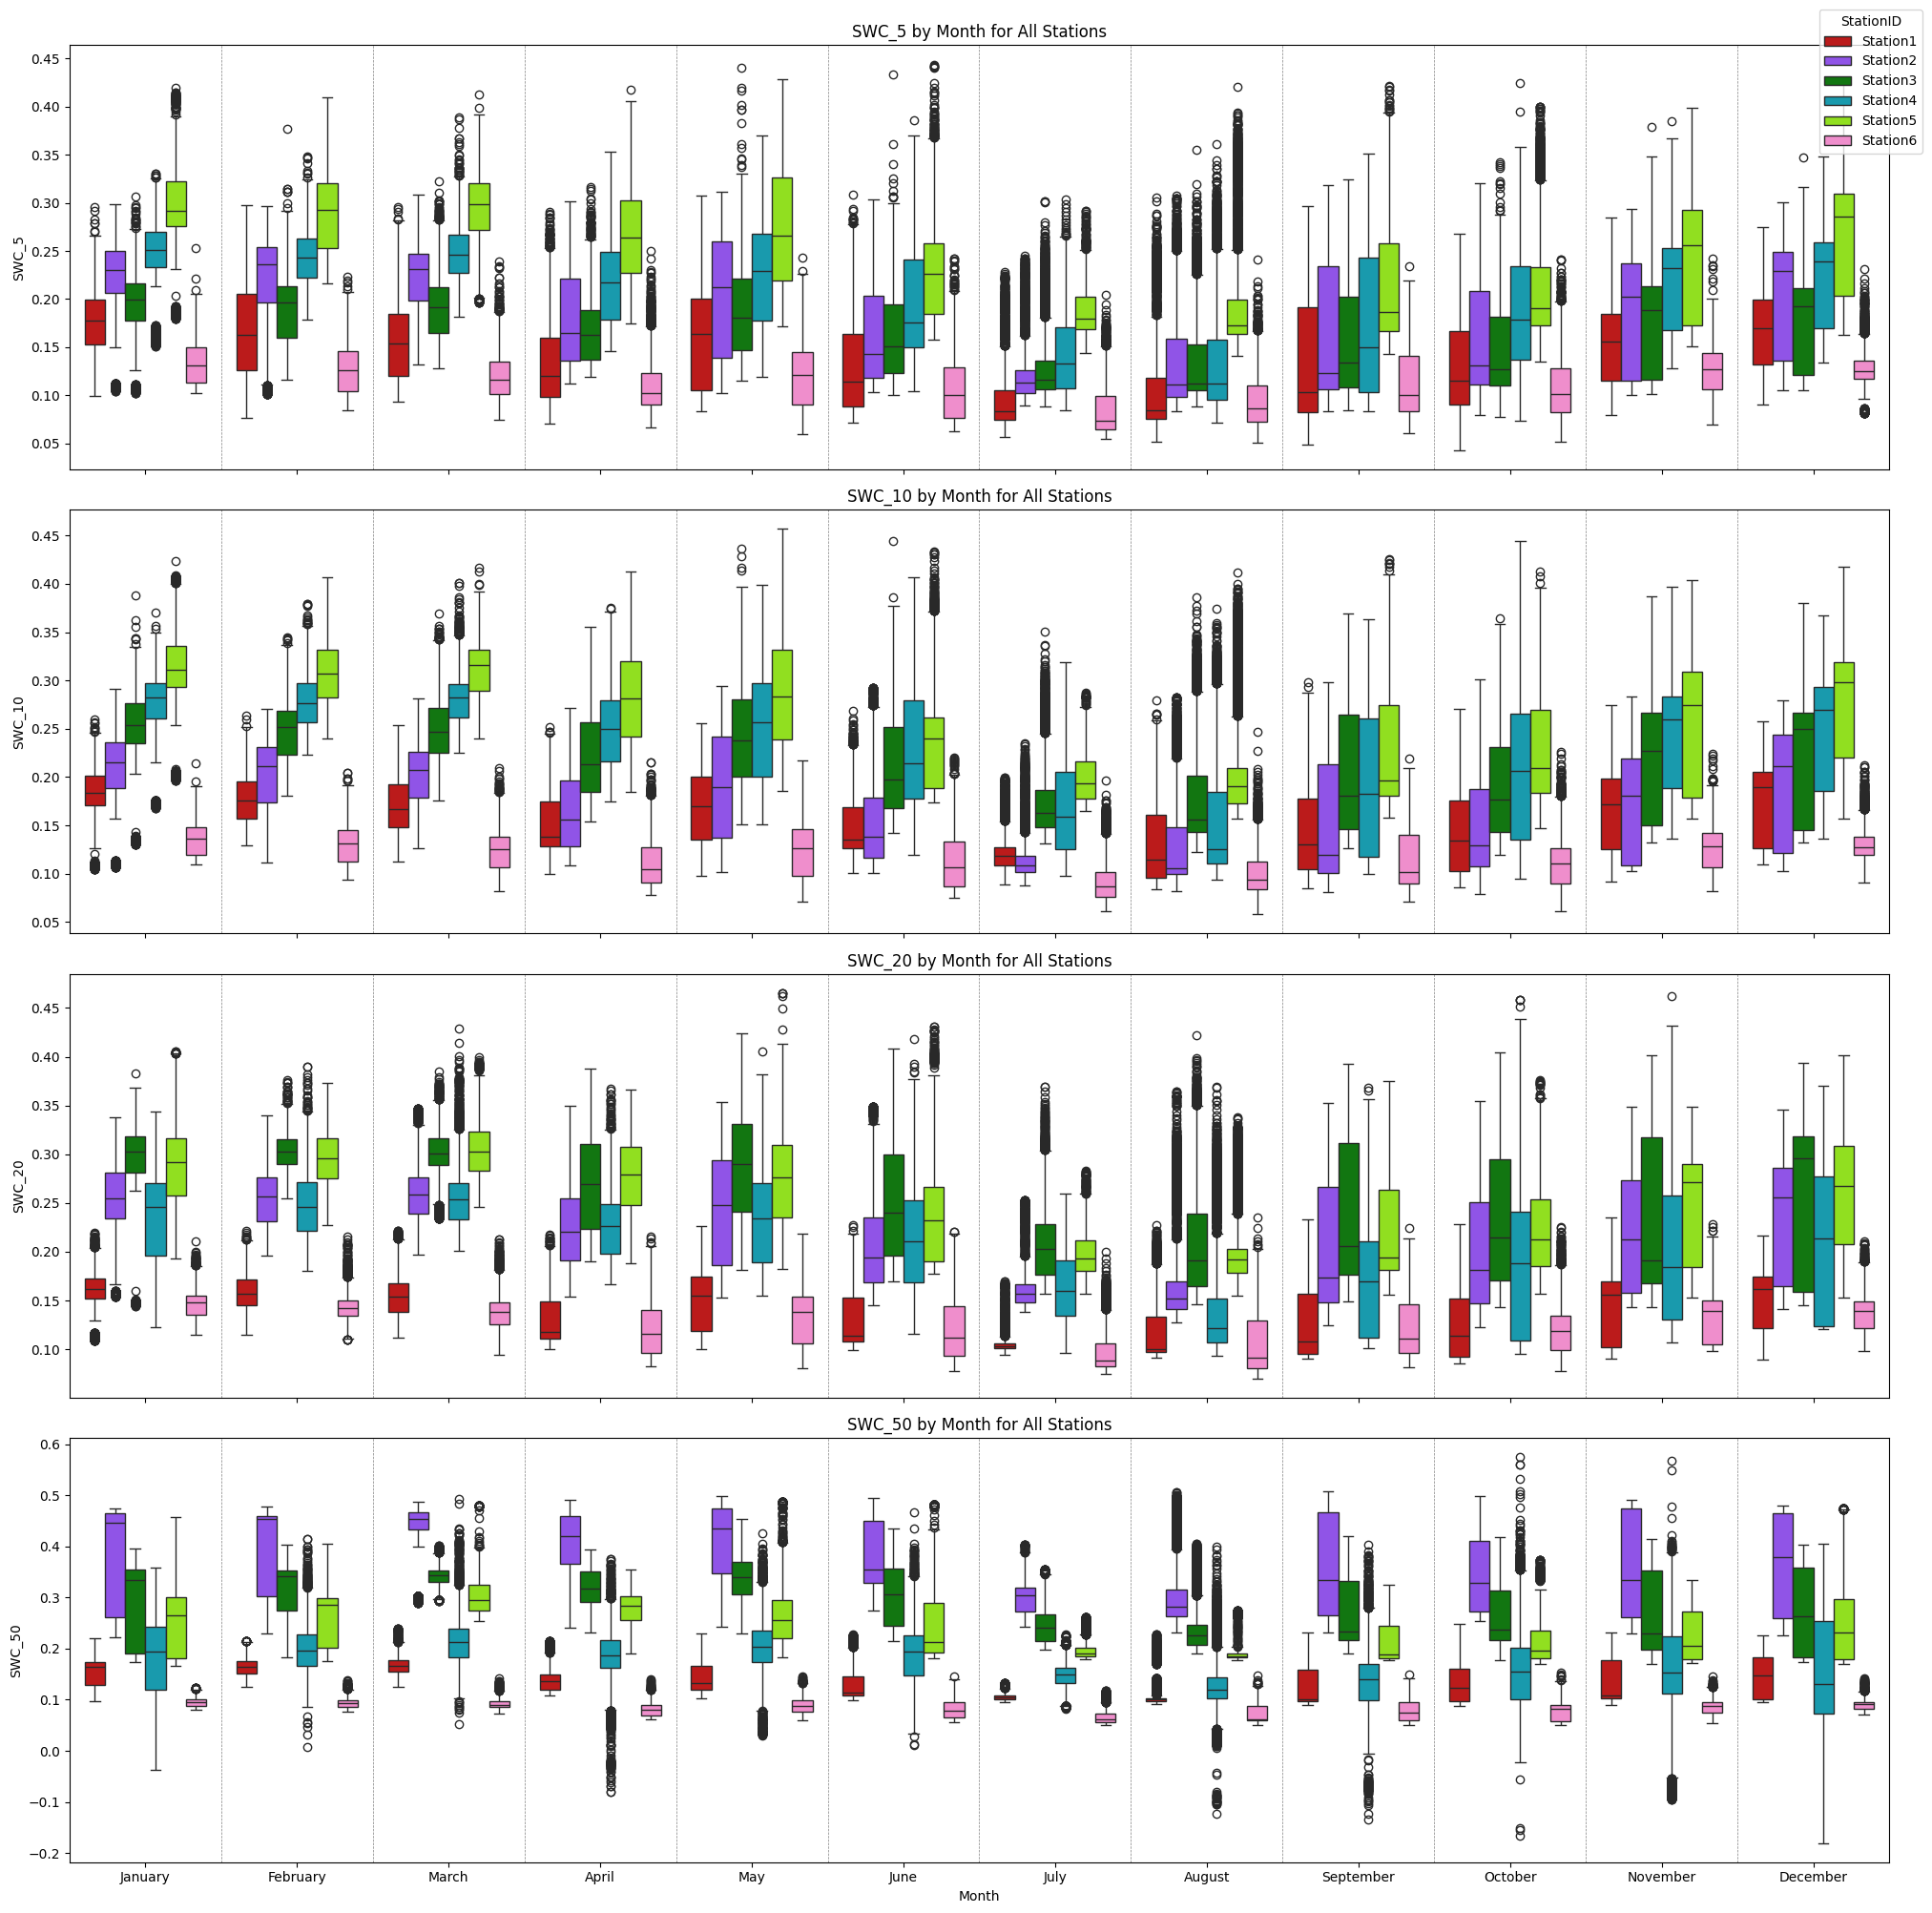

In [14]:
# Plot SWC data from all 6 stations as boxplots side-by-side
fig, axes = plt.subplots(4, 1, figsize = (20, 20), sharex = True)
legend_handles, legend_labels = None, None
palette = sns.color_palette(cc.glasbey, n_colors = 6)
num_months = df_all['Month'].nunique()

for i, (name, ax) in enumerate(zip(['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50'], axes)):
    sns.boxplot(data = df_all, x = 'Month', y = name, hue = 'StationID', ax = ax, palette = palette)
    ax.set_ylabel(name)
    ax.set_title(f'{name} by Month for All Stations')

    if i == len(axes) - 1:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.legend_.remove()

    for j in range(num_months - 1):
        ax.axvline(x = j + 0.5, color = 'grey', linestyle = '--', lw = 0.5)

plt.tight_layout()
fig.legend(legend_handles, legend_labels, loc = 'upper right', title = 'StationID', bbox_to_anchor = (1.01, 1), borderaxespad = 0.)
plt.show()

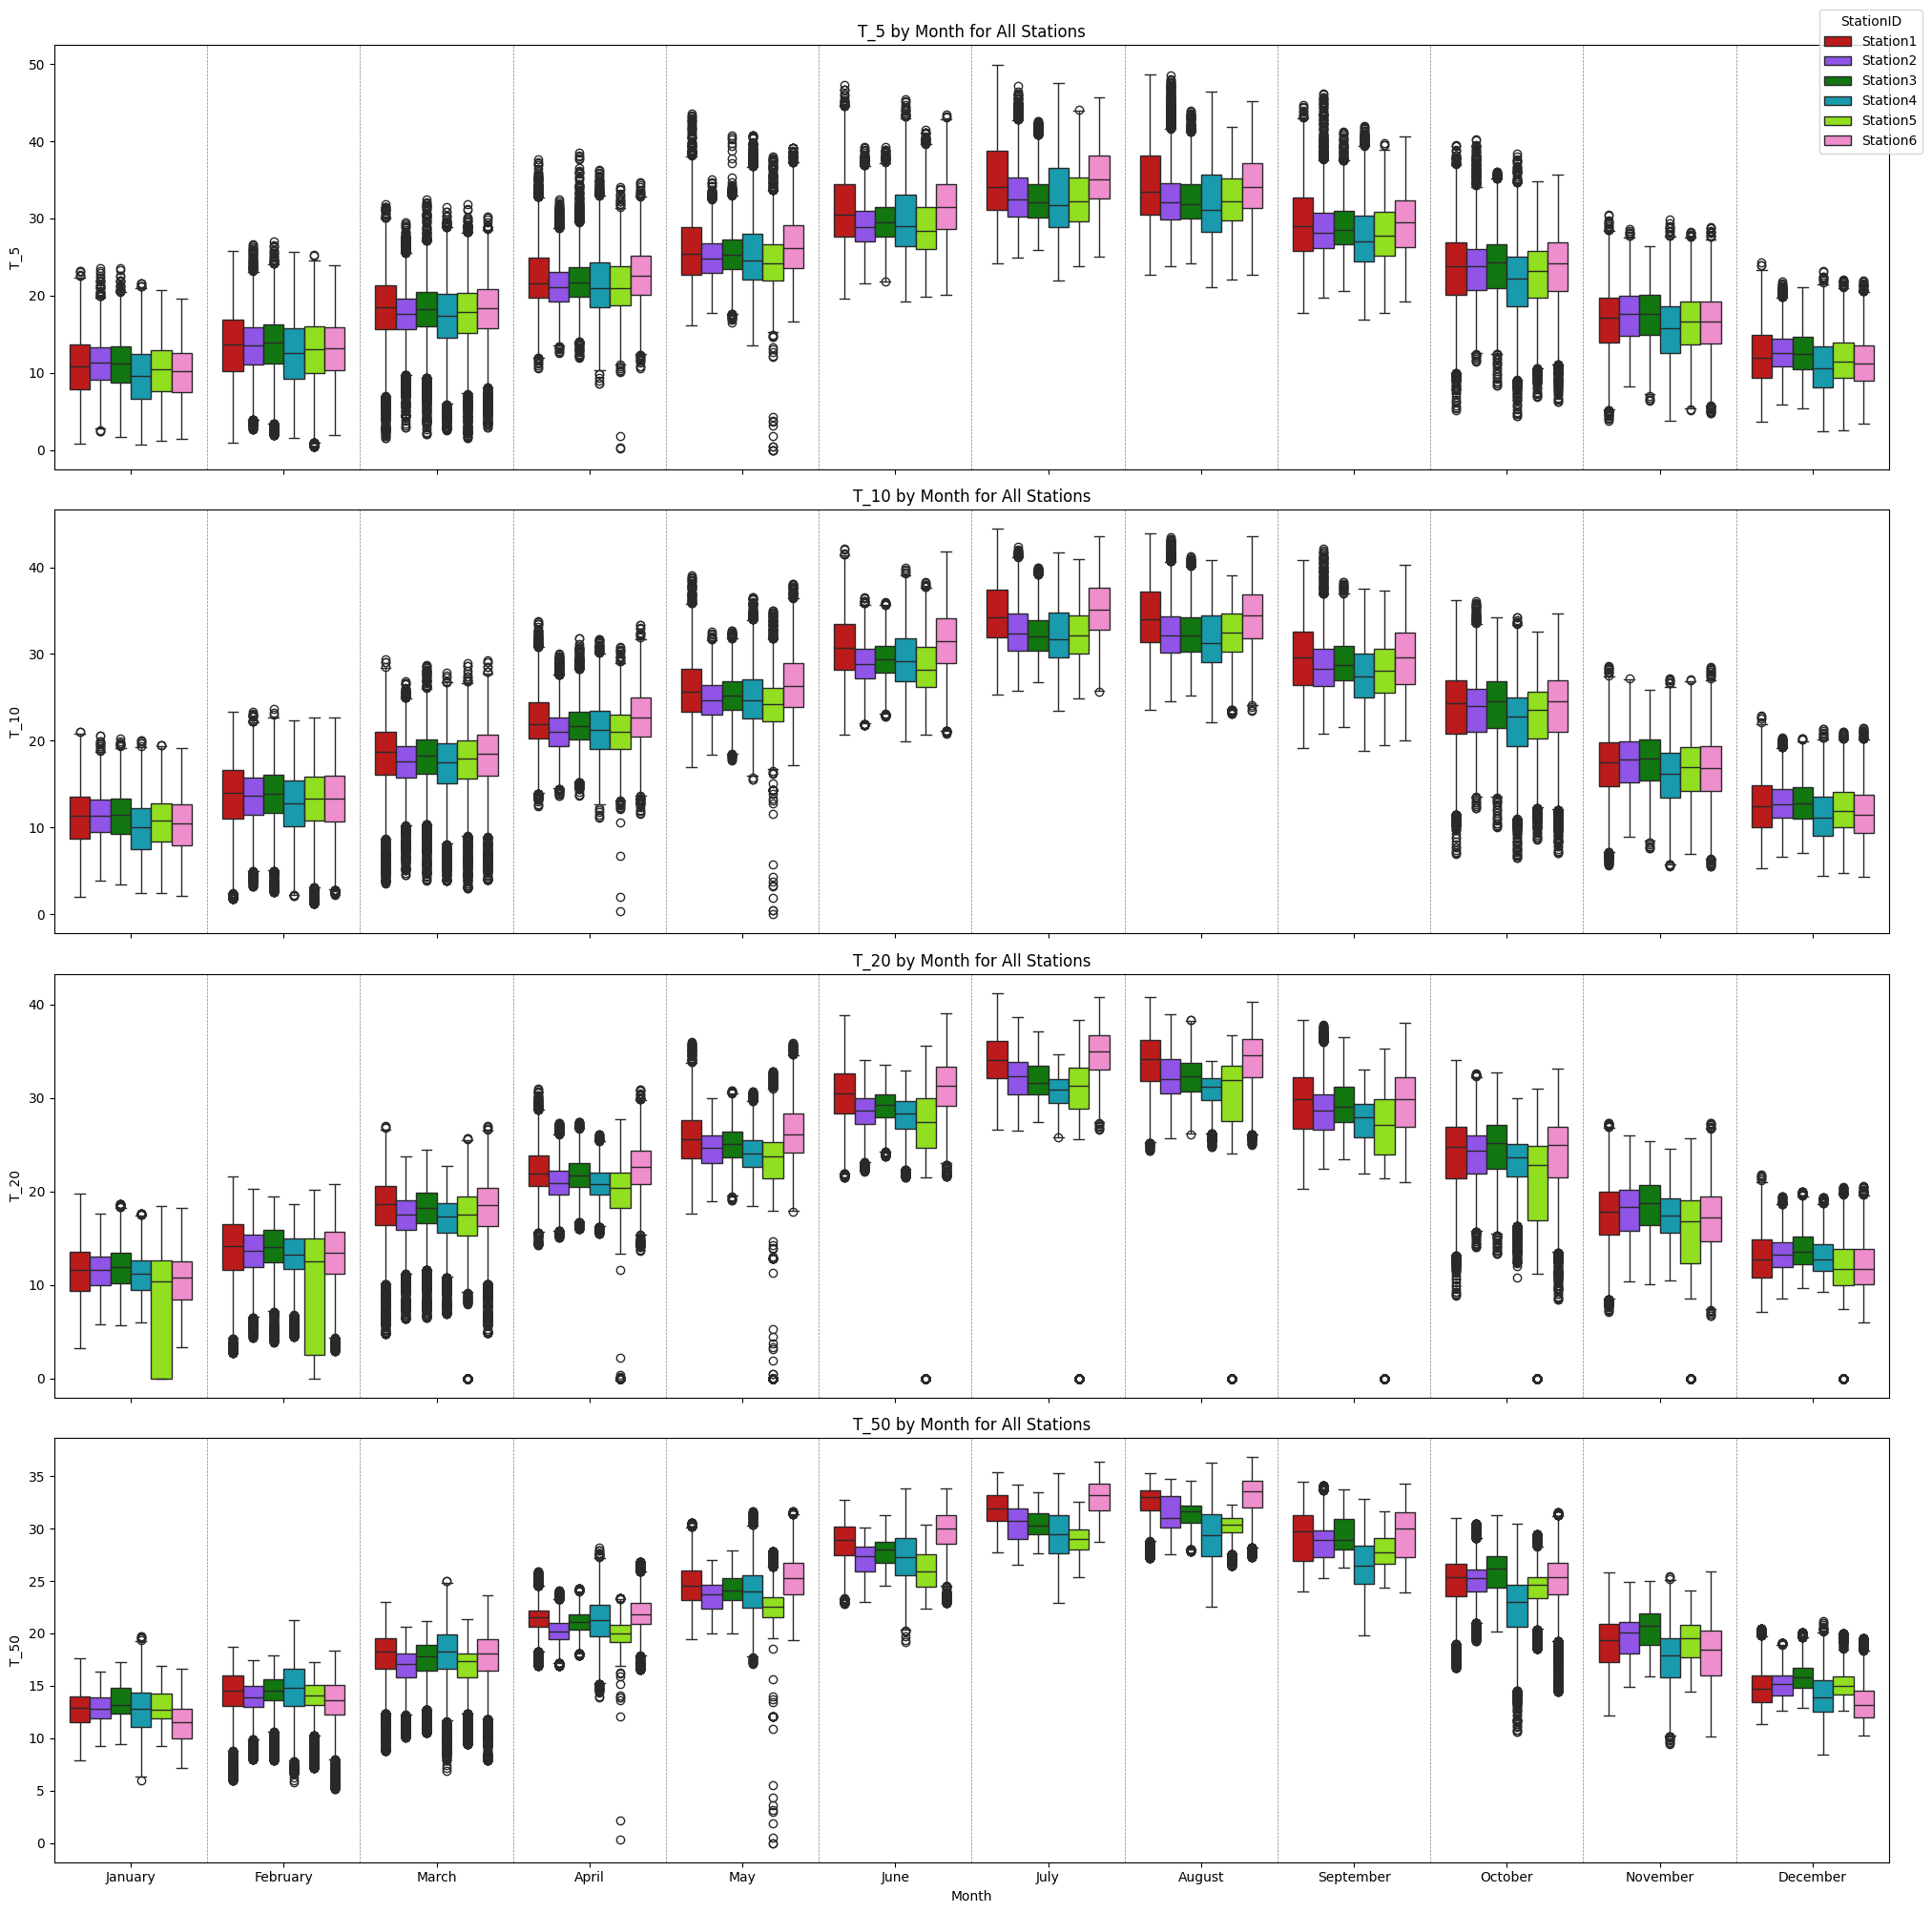

In [15]:
# Plot Soil Temperature data from all 6 stations as boxplots side-by-side
fig, axes = plt.subplots(4, 1, figsize = (20, 20), sharex = True)
legend_handles, legend_labels = None, None
palette = sns.color_palette(cc.glasbey, n_colors = 6)
num_months = df_all['Month'].nunique()

for i, (name, ax) in enumerate(zip(['T_5', 'T_10', 'T_20', 'T_50'], axes)):
    sns.boxplot(data = df_all, x = 'Month', y = name, hue = 'StationID', ax = ax, palette = palette)
    ax.set_ylabel(name)
    ax.set_title(f'{name} by Month for All Stations')

    if i  ==  len(axes) - 1:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.legend_.remove()

    for j in range(num_months - 1):
        ax.axvline(x = j + 0.5, color = 'grey', linestyle = '--', lw = 0.5)

plt.tight_layout()
fig.legend(legend_handles, legend_labels, loc = 'upper right', title = 'StationID', bbox_to_anchor = (1.01, 1), borderaxespad = 0.)
plt.show()

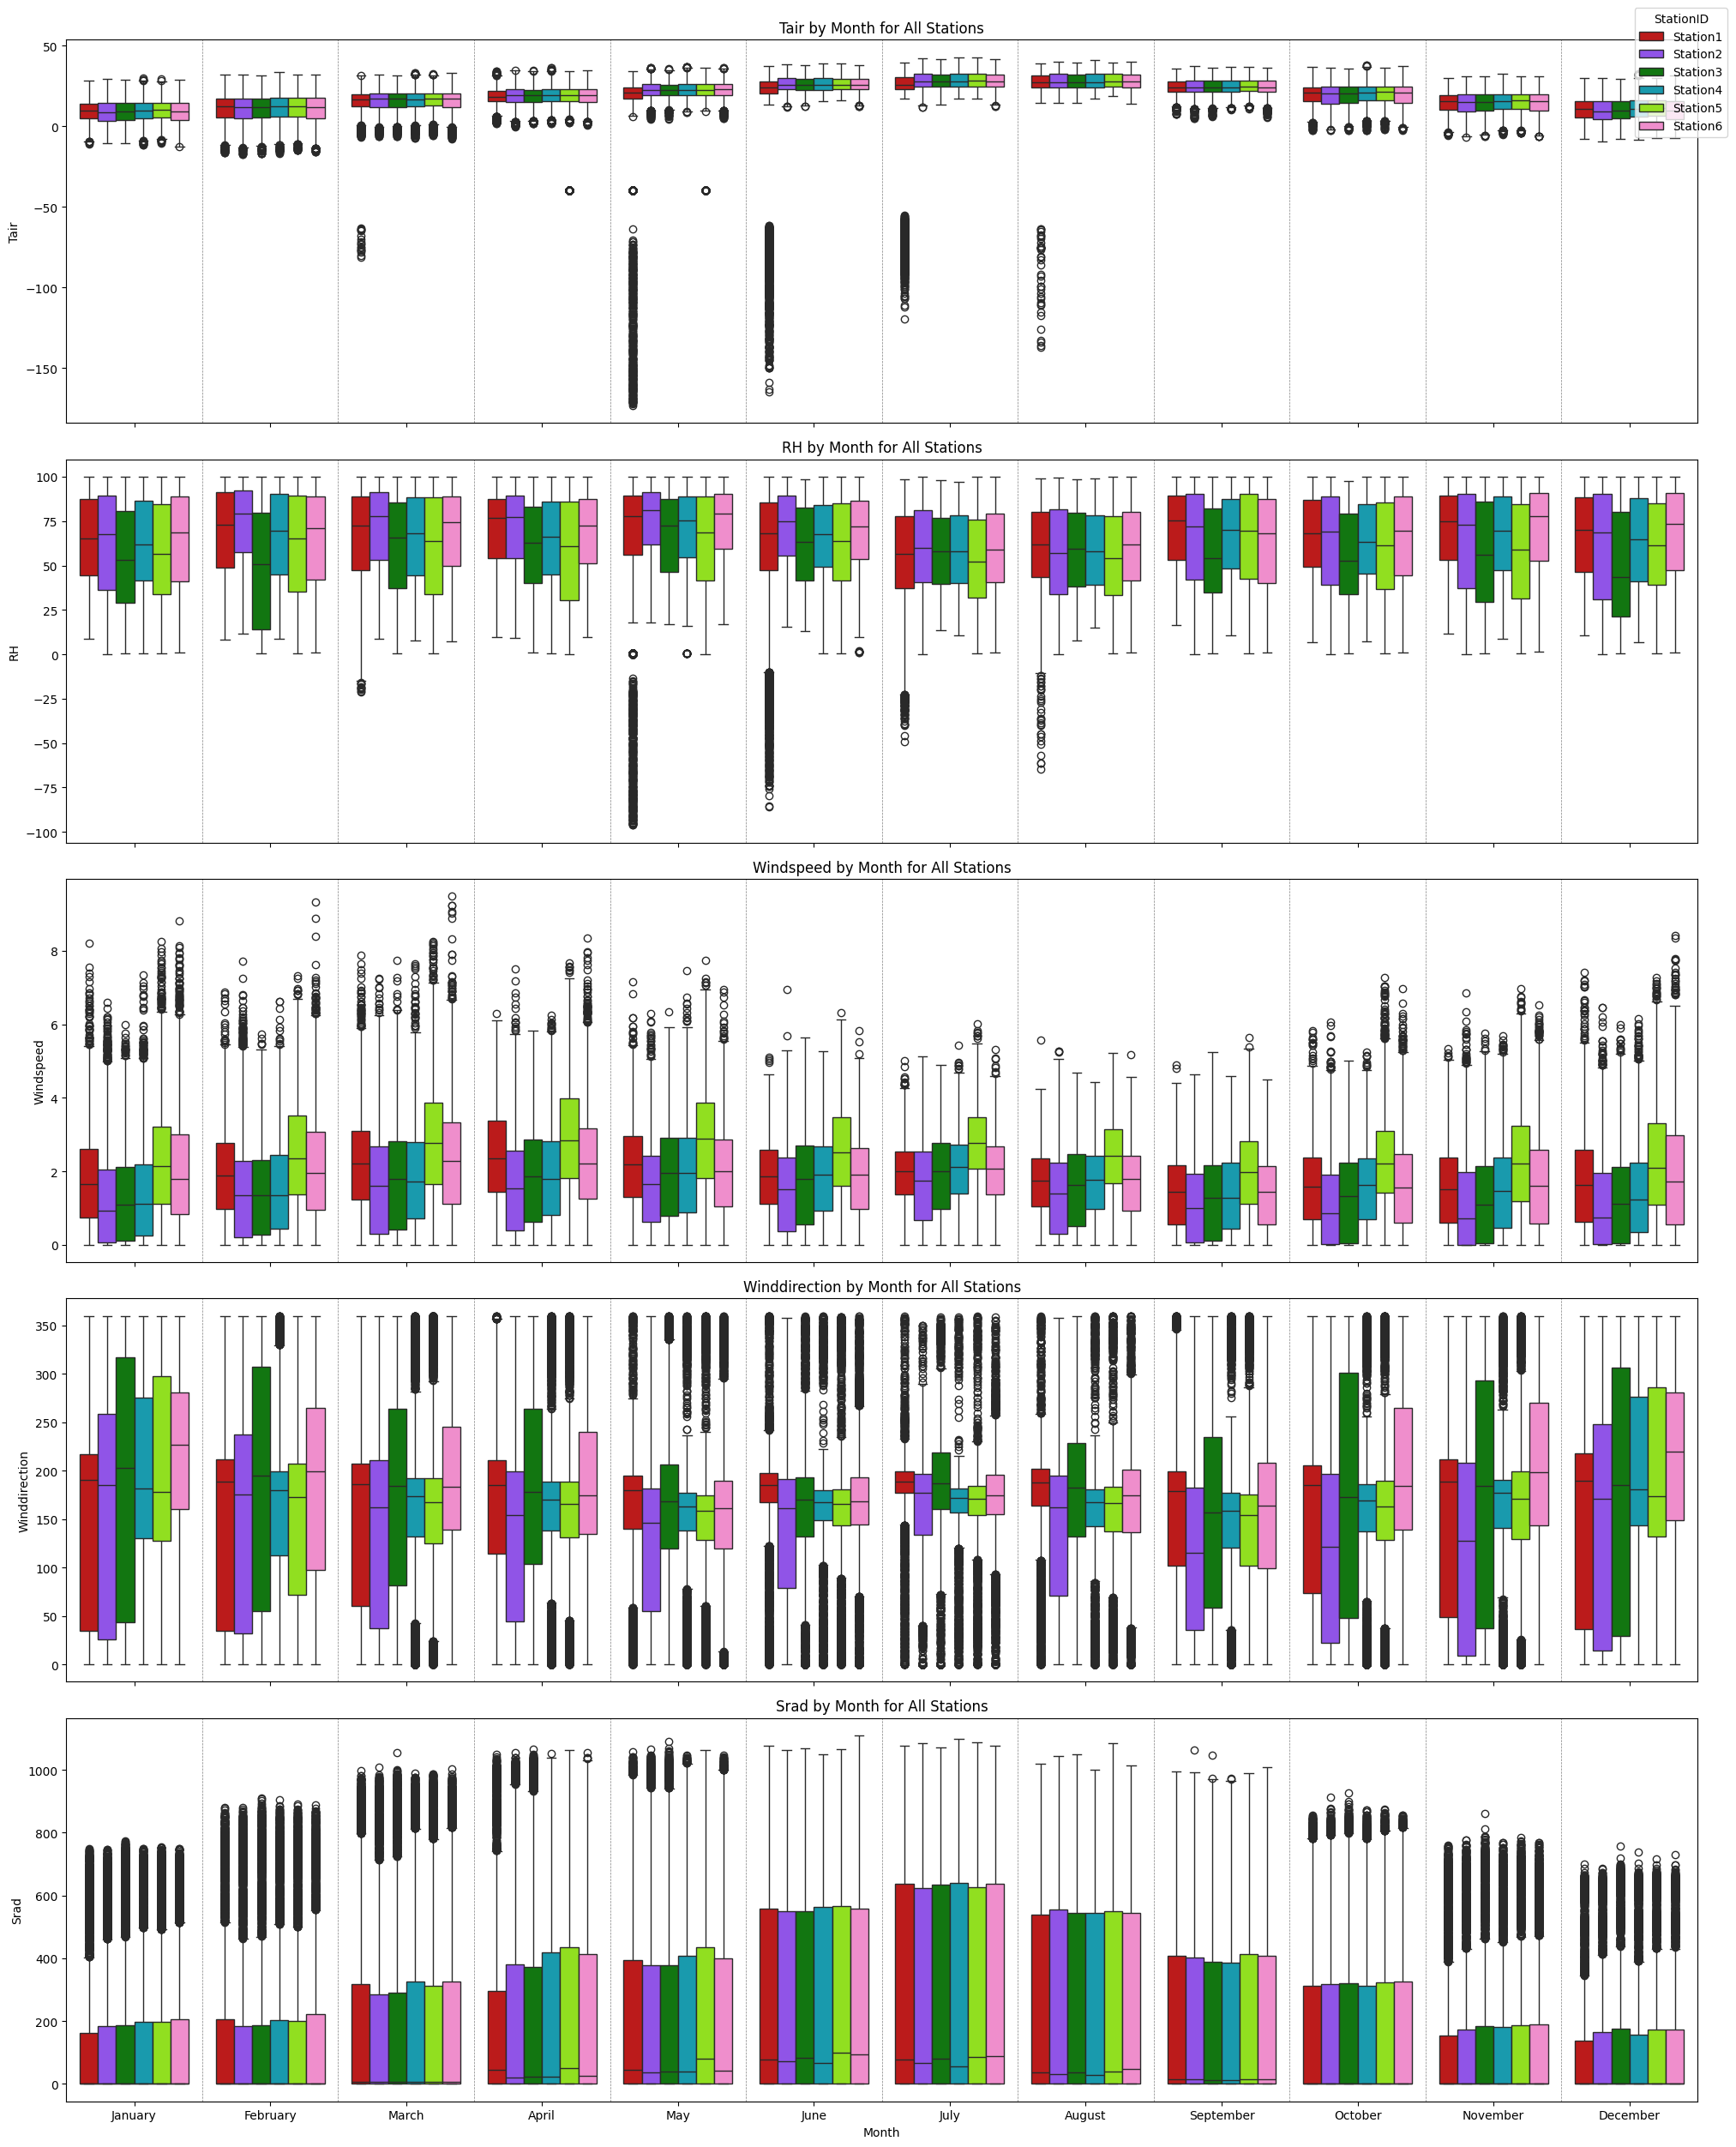

In [16]:
# Plot Miscellaneous data from all 6 stations as boxplots side-by-side
fig, axes = plt.subplots(5, 1, figsize = (20, 25), sharex = True)
legend_handles, legend_labels = None, None
palette = sns.color_palette(cc.glasbey, n_colors = 6)
num_months = df_all['Month'].nunique()

for i, (name, ax) in enumerate(zip(['Tair', 'RH', 'Windspeed', 'Winddirection', 'Srad'], axes)):
    sns.boxplot(data = df_all, x = 'Month', y = name, hue = 'StationID', ax = ax, palette = palette)
    ax.set_ylabel(name)
    ax.set_title(f'{name} by Month for All Stations')

    if i  ==  len(axes) - 1:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.legend_.remove()

    for j in range(num_months - 1):
        ax.axvline(x = j + 0.5, color = 'grey', linestyle = '--', lw = 0.5)

plt.tight_layout()
fig.legend(legend_handles, legend_labels, loc = 'upper right', title = 'StationID', bbox_to_anchor = (1.01, 1), borderaxespad = 0.)
plt.show()

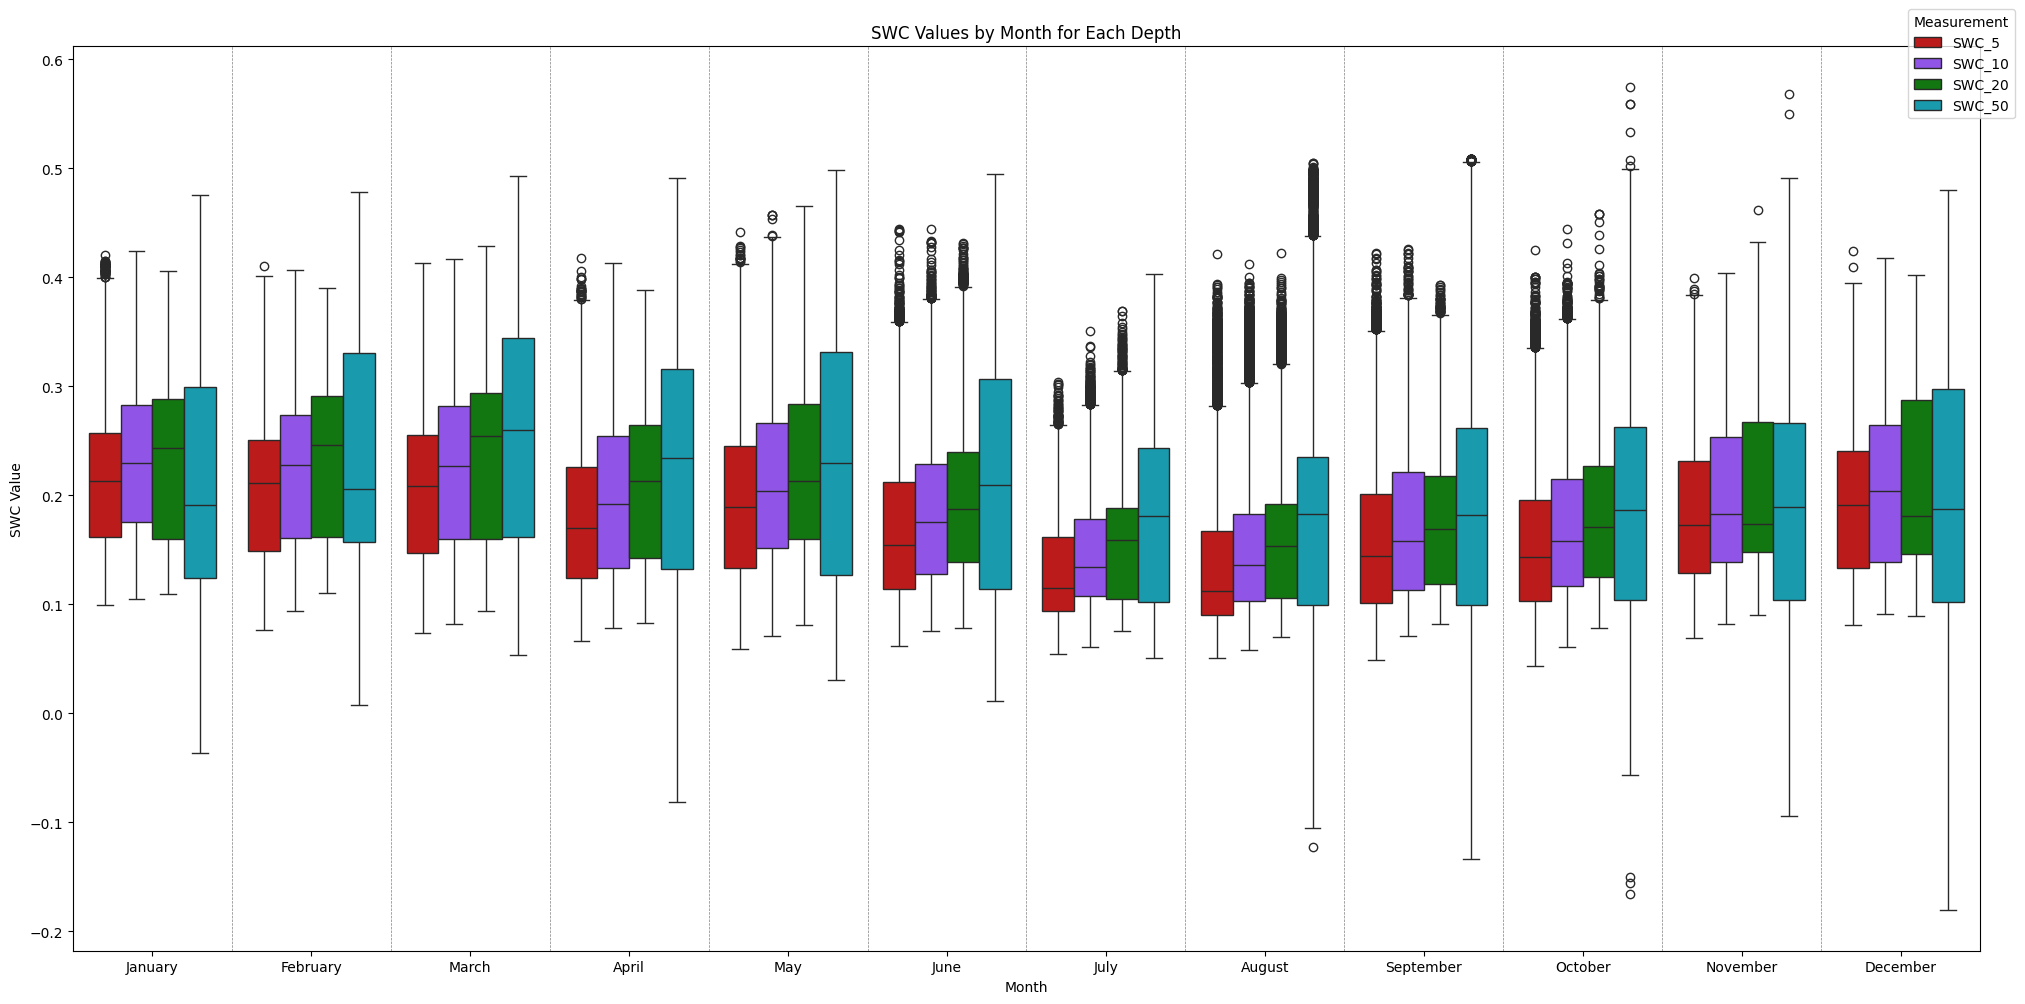

In [17]:
# Compare the different soil water content depths against each other
df_melted = df_all.melt(id_vars = ['Month', 'StationID'],
                        value_vars = ['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50'],
                        var_name = 'Measurement', value_name = 'Value')

fig, ax = plt.subplots(1, 1, figsize = (20, 10))

palette = sns.color_palette(cc.glasbey, n_colors = 4)
sns.boxplot(data = df_melted, x = 'Month', y = 'Value', hue = 'Measurement', ax = ax, palette = palette)
ax.set_ylabel('SWC Value')
ax.set_title('SWC Values by Month for Each Depth')

num_months = df_melted['Month'].nunique()
for j in range(num_months - 1):
    ax.axvline(x = j + 0.5, color = 'grey', linestyle = '--', lw = 0.5)

legend_handles, legend_labels = ax.get_legend_handles_labels()
fig.legend(legend_handles, legend_labels, loc = 'upper right', title = 'Measurement', bbox_to_anchor = (1.01, 1), borderaxespad = 0.)

ax.legend_.remove()

plt.tight_layout()
plt.show()

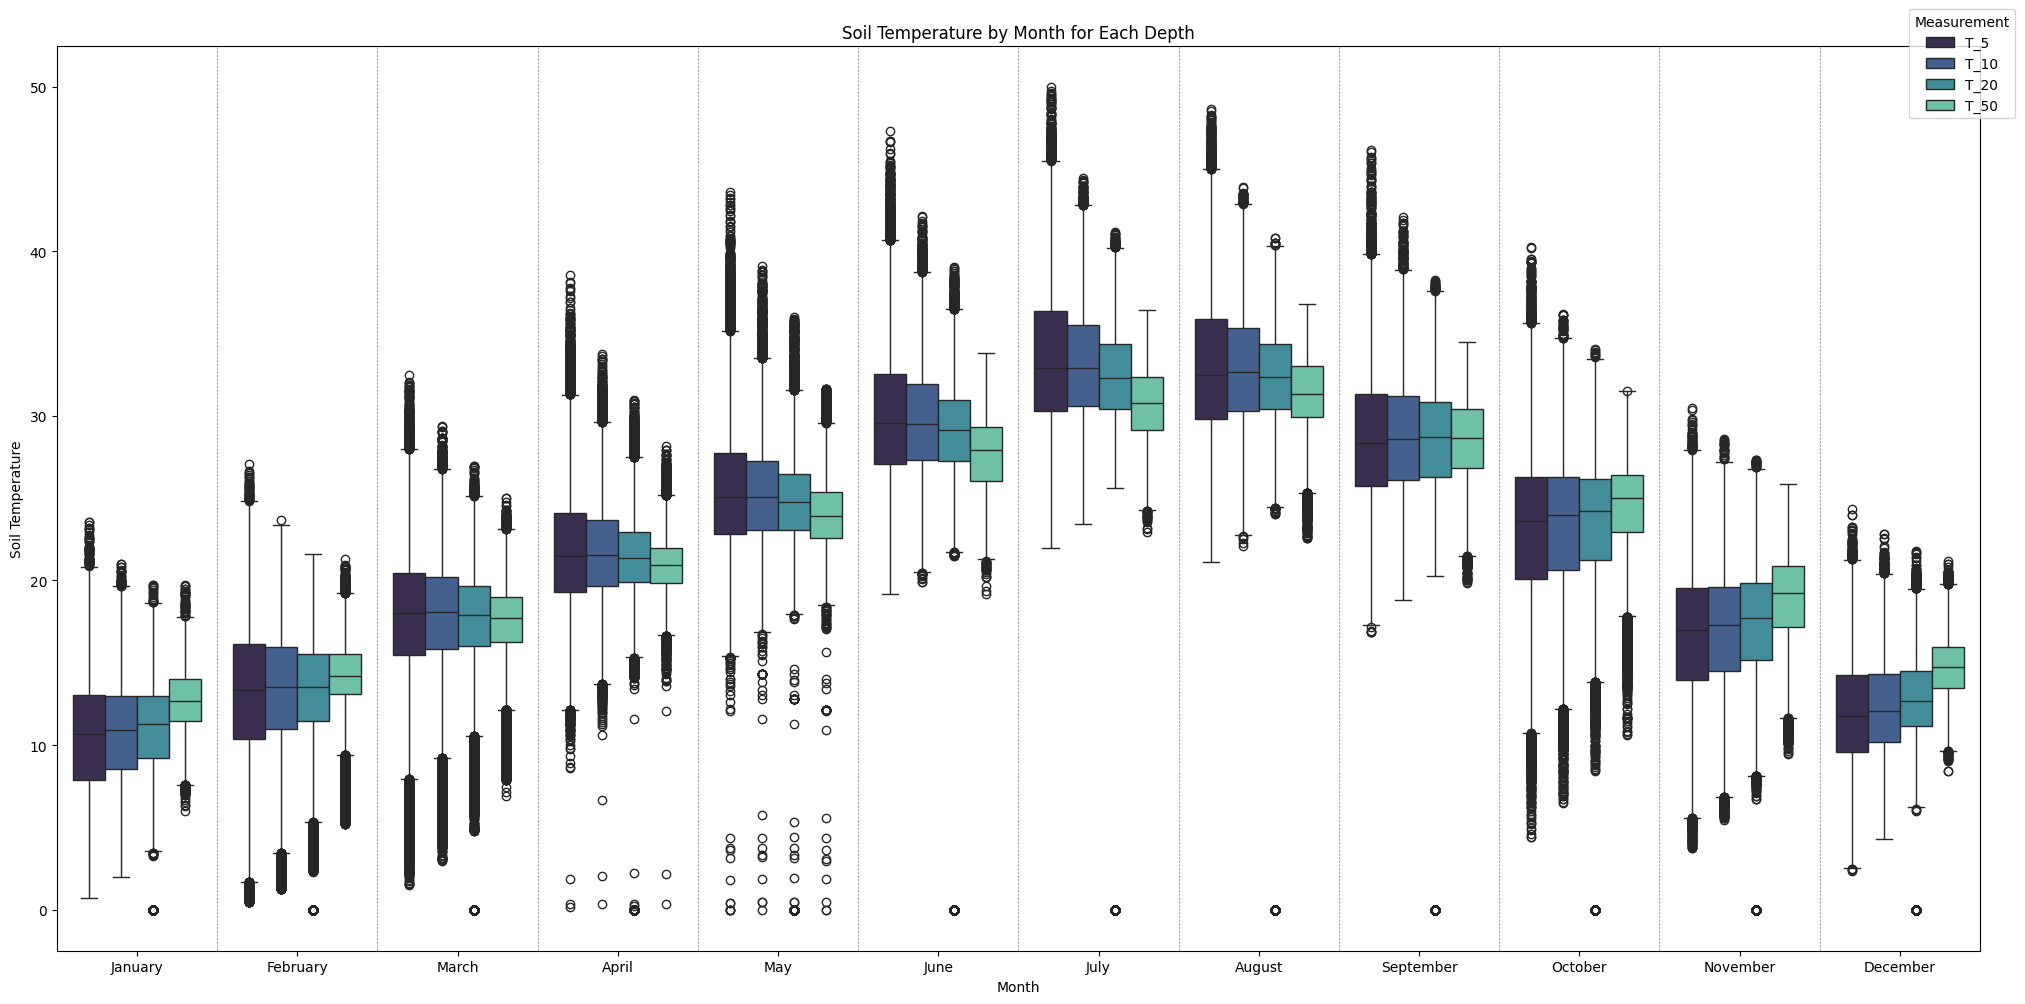

In [18]:
# Compare the different soil temperatures depths against each other
df_melted_temp = df_all.melt(id_vars = ['Month', 'StationID'],
                             value_vars = ['T_5', 'T_10', 'T_20', 'T_50'],
                             var_name = 'Measurement', value_name = 'Temperature')

fig, ax = plt.subplots(1, 1, figsize = (20, 10))

palette = sns.color_palette("mako", n_colors = 4)
sns.boxplot(data = df_melted_temp, x = 'Month', y = 'Temperature', hue = 'Measurement', ax = ax, palette = palette)
ax.set_ylabel('Soil Temperature')
ax.set_title('Soil Temperature by Month for Each Depth')

num_months = df_melted_temp['Month'].nunique()
for j in range(num_months - 1):
    ax.axvline(x = j + 0.5, color = 'grey', linestyle = '--', lw = 0.5)

legend_handles, legend_labels = ax.get_legend_handles_labels()
fig.legend(legend_handles, legend_labels, loc = 'upper right', title = 'Measurement', bbox_to_anchor = (1.01, 1), borderaxespad = 0.)

ax.legend_.remove()

plt.tight_layout()
plt.show()